# POS: identificar la función gramatical de cada palabra

En NER buscamos nombres de entidades. Aquí etiquetamos **todas las palabras** con una de 17 categorías UPOS: nombre, verbo, adjetivo, etc.

Este notebook ejecutado **lee una ejecución real guardada**, realizada con `src/pos_experiment.py`; no vuelve a entrenar. Los historiales, predicciones y modelos permiten comprobar los resultados. Para entrenar desde cero, consultar POS_GUIDE.md.

## Hipótesis y protocolo
Comparamos un cuerpo BERT congelado con ajuste parcial de sus últimas dos capas. Ambas alternativas usan la misma cabeza lineal, semilla 42, tres épocas y datos oficiales de UD English EWT r2.15. Seleccionamos época y método por **accuracy de palabras en validación**, con desempate entre métodos por menor número de parámetros; prueba queda reservada hasta finalizar la selección.

La tasa de aprendizaje de la cabeza es 1e-3 y la del cuerpo entrenable 2e-5. El cuerpo congelado permanece en modo evaluación para desactivar dropout. En el parcial, solo las capas entrenables quedan en modo entrenamiento.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
import torch
torch.set_num_threads(8)
RUN = ROOT / "runs/pos_verified"
sys.path.insert(0, str(ROOT / "src"))
assert json.loads((RUN / "status.json").read_text())["status"] == "complete"
display(pd.read_csv(RUN / "comparison.csv"))

,method,best_epoch,best_val_accuracy,trainable_parameters,total_parameters,frozen_parameters_verified,train_seconds,peak_allocated_gpu_bytes,test_loss,test_token_accuracy,test_macro_f1,selected
0,frozen,3,0.931250,13073,108904721,True,79.851557,554948096,0.233856,0.932295,0.865129,False
1,partial_finetuning,3,0.958845,14188817,108904721,True,110.286533,867813376,0.139393,0.957320,0.897513,True


## Datos y alineación
Las filas de CoNLL-U que representan contracciones completas y nodos vacíos se omiten siguiendo el formato UD; se conservan las palabras sintácticas. Una etiqueta ausente o desconocida produce un error: no se inventa una categoría adicional.

BERT divide algunas palabras en varias piezas. Solo la primera recibe la etiqueta de la palabra; las otras piezas, símbolos especiales y padding reciben -100 y no participan en la pérdida. Se comprueba que ninguna palabra desaparezca. No se truncan frases. Los ejemplos repetidos entre particiones se auditan y conservan para respetar el benchmark.

In [2]:
manifest = json.loads((RUN / "data_manifest.json").read_text())
display({k:manifest[k] for k in ["split_sizes", "max_subtoken_lengths", "cross_split_exact_sentence_overlaps", "labels"]})
display(pd.read_csv(RUN / "alignment_check.csv").head(45))

{'split_sizes': {'train': 12544, 'validation': 2001, 'test': 2077},
 'max_subtoken_lengths': {'train': 176, 'validation': 90, 'test': 337},
 'cross_split_exact_sentence_overlaps': {'train/validation': 36,
  'train/test': 47,
  'validation/test': 27},
 'labels': ['ADJ',
  'ADP',
  'ADV',
  'AUX',
  'CCONJ',
  'DET',
  'INTJ',
  'NOUN',
  'NUM',
  'PART',
  'PRON',
  'PROPN',
  'PUNCT',
  'SCONJ',
  'SYM',
  'VERB',
  'X']}

,batch_row,source_row,position,subtoken,word,label_id,label
0,0,0,0,[CLS],NaN,-100,IGNORE
1,0,0,1,al,Al,11,PROPN
2,0,0,2,-,-,12,PUNCT
3,0,0,3,za,Zaman,11,PROPN
4,0,0,4,##man,Zaman,-100,IGNORE
5,0,0,5,:,:,12,PUNCT
6,0,0,6,american,American,0,ADJ
7,0,0,7,forces,forces,7,NOUN
8,0,0,8,killed,killed,15,VERB
9,0,0,9,sha,Shaikh,11,PROPN


## Aprendizaje y selección
La pérdida mide el error de las probabilidades; accuracy mide la proporción de palabras bien etiquetadas. Macro-F1 da el mismo peso a cada una de las 17 categorías y permite detectar desempeño desigual en categorías raras. Los tiempos incluyen entrenamiento, no validación ni guardado, y no miden latencia de inferencia.

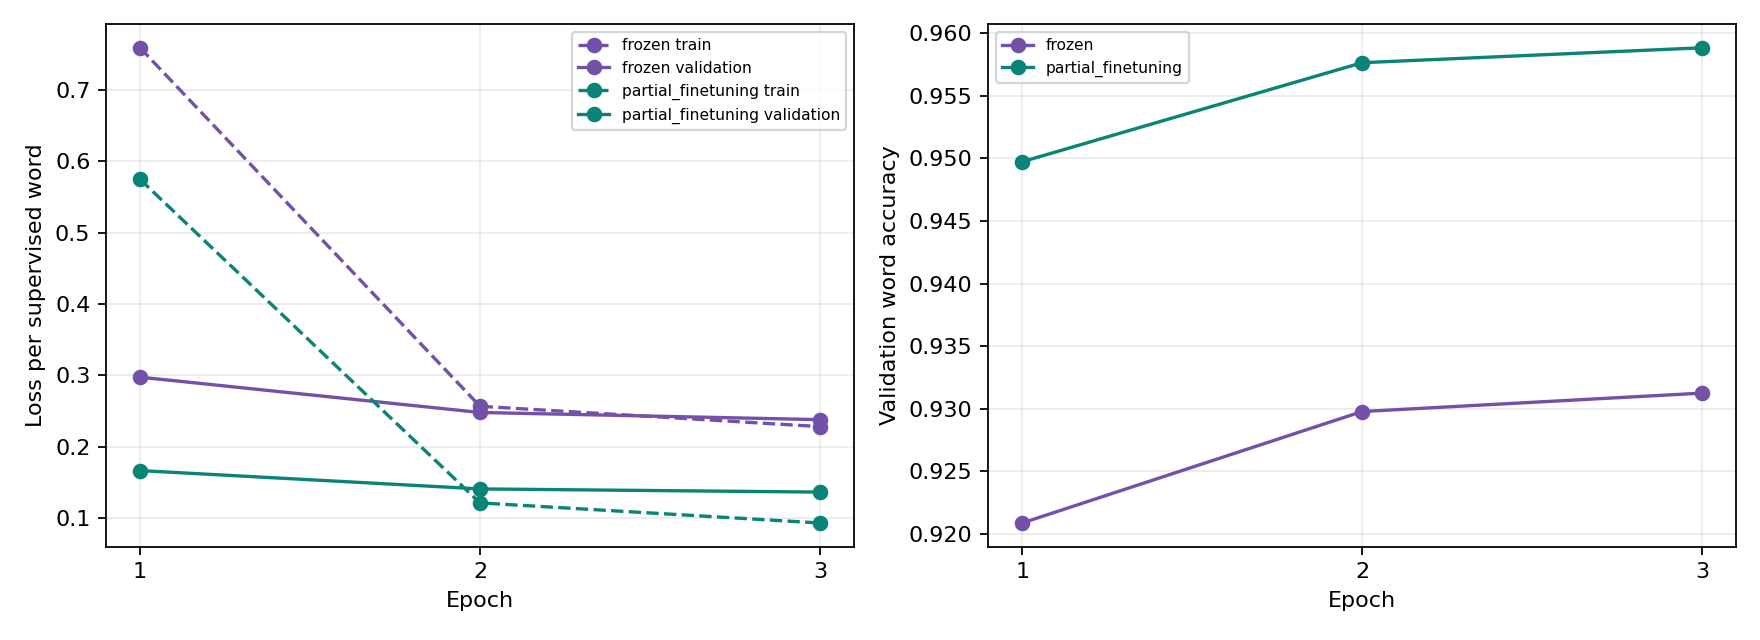

frozen


,epoch,train_loss,train_seconds,validation_seconds,val_loss,val_token_accuracy,val_macro_f1
0,1,0.758623,27.069167,4.113057,0.297665,0.920872,0.843444
1,2,0.256946,25.707940,4.005467,0.248267,0.929779,0.864878
2,3,0.228490,27.074450,3.996520,0.238211,0.931250,0.868227


partial_finetuning


,epoch,train_loss,train_seconds,validation_seconds,val_loss,val_token_accuracy,val_macro_f1
0,1,0.574518,36.396072,4.406401,0.166937,0.949740,0.882412
1,2,0.121722,37.014004,3.784843,0.141265,0.957652,0.897302
2,3,0.093580,36.876457,3.906841,0.136842,0.958845,0.897515


{'winner': 'partial_finetuning',
 'criterion': 'maximum word accuracy on validation; exact tie: fewer trainable parameters',
 'single_seed': True,
 'test_used_for_selection': False,
 'smoke': False}

In [3]:
display(Image(filename=str(RUN / "learning_curves.png")))
for method in ["frozen", "partial_finetuning"]:
    print(method)
    display(pd.read_csv(RUN / method / "history.csv"))
display(json.loads((RUN / "selection.json").read_text()))

## Verificación independiente de predicciones
Recalculamos accuracy y macro-F1 a partir de las predicciones guardadas, sin volver a usar el modelo ni el evaluador de entrenamiento.

In [4]:
from sklearn.metrics import accuracy_score, f1_score
for method in ["frozen", "partial_finetuning"]:
    rows = [json.loads(x) for x in (RUN / method / "test_predictions.jsonl").read_text(encoding="utf-8").splitlines()]
    gold = [t for r in rows for t in r["reference"]]
    pred = [t for r in rows for t in r["prediction"]]
    saved = json.loads((RUN / method / "test_metrics.json").read_text())
    acc = accuracy_score(gold, pred)
    f1 = f1_score(gold, pred, labels=manifest["labels"], average="macro", zero_division=0)
    assert abs(acc-saved["token_accuracy"]) < 1e-12
    assert abs(f1-saved["macro_f1"]) < 1e-12
    print(method, "palabras",len(gold),"accuracy",acc,"macro-F1",f1)
    errors = json.loads((RUN / method / "error_analysis.json").read_text())
    display(pd.DataFrame(errors["top_confusions"]).head(10))
    display(pd.DataFrame(errors["examples"]).head(5))

frozen palabras 25094 accuracy 0.9322945724077468 macro-F1 0.865129357866465


,gold,prediction,count
0,PROPN,NOUN,228
1,NOUN,PROPN,119
2,ADJ,NOUN,102
3,NOUN,ADJ,78
4,AUX,PUNCT,58
5,ADJ,VERB,55
6,VERB,ADJ,50
7,ADV,ADJ,49
8,ADV,ADP,47
9,ADJ,PROPN,46


,source_row,word,gold,prediction,sentence
0,0,What,PRON,ADJ,What if Google Morphed Into GoogleOS ?
1,1,What,PRON,ADJ,What if Google expanded on its search - engine...
2,1,e-mail,NOUN,ADJ,What if Google expanded on its search - engine...
3,1,full,ADV,ADJ,What if Google expanded on its search - engine...
4,2,Watch,PROPN,NOUN,[ via Microsoft Watch from Mary Jo Foley ]


partial_finetuning palabras 25094 accuracy 0.9573204750139476 macro-F1 0.8975131951071644


,gold,prediction,count
0,PROPN,NOUN,180
1,NOUN,PROPN,109
2,ADJ,NOUN,64
3,NOUN,ADJ,60
4,ADV,ADJ,35
5,ADJ,VERB,35
6,PROPN,ADJ,34
7,VERB,ADJ,33
8,ADV,ADP,30
9,ADJ,PROPN,26


,source_row,word,gold,prediction,sentence
0,0,What,PRON,ADJ,What if Google Morphed Into GoogleOS ?
1,1,full,ADV,ADJ,What if Google expanded on its search - engine...
2,3,else,ADJ,PRON,"( And , by the way , is anybody else just a li..."
3,6,Does,AUX,VERB,Does anybody use it for anything else ?
4,10,across,ADP,VERB,I doubt the very few who actually read my blog...


## Recarga del modelo exportado
Esta inferencia nueva se realiza en CPU con el modelo y tokenizer del directorio entregable. No se usa para elegir el ganador. La salida corresponde a palabras pretokenizadas y al primer subtoken de cada palabra.

In [5]:
from transformers import AutoModelForTokenClassification, AutoTokenizer
from pos_experiment import predict_words
folder = RUN / "delivered_model_pos"
model = AutoModelForTokenClassification.from_pretrained(folder)
tokenizer = AutoTokenizer.from_pretrained(folder)
words = ["John", "bought", "beautiful", "flowers", "."]
display(pd.DataFrame({"palabra":words,"UPOS":predict_words(model, tokenizer, words)}))
del model

C:\Users\IGNITER\Documents\ChatGPT\Cosas Escuela 2\.venv-agnews\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,palabra,UPOS
0,John,PROPN
1,bought,VERB
2,beautiful,ADJ
3,flowers,NOUN
4,.,PUNCT


## Qué podemos concluir
La comparación muestra cuánto aporta adaptar las últimas capas bajo esta configuración. No demuestra que cualquier ajuste parcial supere a cualquier clasificador congelado. Solo usamos una semilla y no buscamos hiperparámetros con prueba.

El modelo es inglés y uncased: no está validado para español. Los errores entre NOUN y PROPN pueden estar relacionados con múltiples factores; las métricas no prueban una causa. Revisa los ejemplos antes de atribuirlos a la eliminación de mayúsculas.

Procedencia: [UD English EWT r2.15](https://github.com/UniversalDependencies/UD_English-EWT/tree/r2.15), [formato CoNLL-U](https://universaldependencies.org/format.html). SHA256 de las fuentes y versiones exactas del entorno quedan guardadas en la ejecución. Modelo local; publicación pendiente.